<a href="https://colab.research.google.com/github/GilTaeho/XAI_study-/blob/main/xai%EA%B5%90%EC%9E%AC%EC%8B%A4%EC%8A%B5ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 %tensorflow_version 2.x

%pip install shap

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
%matplotlib inline

loan_data=pd.read_csv('https://raw.githubusercontent.com/JaehyunAhn/XAI_dataset/master/Ch1.loan/loanData.csv')
loan_data.tail()

,id,gender,age,married,dependents,education,self_employed,business_type,applicant_income,applicant_work_period,coapplicant_income,credit_history,credit_amount,property_area,property_type,credit_rate,loan_amount,loan_term,loan_status
609,LA001350,Male,22,Yes,NaN,Graduate,No,43,13650,56,0.0,1.0,759,Urban,1,2,4000,26,1
610,LA001357,Male,24,NaN,NaN,Graduate,No,62,3816,41,754.0,1.0,3190,Urban,1,2,2880,30,1
611,LA001760,Male,25,NaN,NaN,Graduate,No,86,4758,52,0.0,1.0,1747,Semiurban,1,2,2844,34,1
612,LA002943,Male,67,No,NaN,Graduate,No,12,2987,2,0.0,0.0,0,Semiurban,1,2,1760,30,0
613,LA002393,Female,44,NaN,NaN,Graduate,No,94,10047,43,0.0,1.0,1181,Semiurban,2,1,3712,22,1


In [ ]:
loan_data['dependents'].unique()

array(['3+', '2', '1', '0', nan], dtype=object)

In [ ]:
loan_data['gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [ ]:
gendr_mapping={'Male':1,'Female':0,np.nan:-1}
loan_data=loan_data.replace({'gender':gendr_mapping})

loan_data.head()

/tmp/ipykernel_1610/1652846884.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data=loan_data.replace({'gender':gendr_mapping})


,id,gender,age,married,dependents,education,self_employed,business_type,applicant_income,applicant_work_period,coapplicant_income,credit_history,credit_amount,property_area,property_type,credit_rate,loan_amount,loan_term,loan_status
0,LA001250,1.0,55,Yes,3+,Not Graduate,No,88,4755,51,0.0,0.0,0,Semiurban,3,8,2090,0,0
1,LA001864,1.0,68,Yes,3+,Not Graduate,No,14,4931,47,0.0,NaN,0,Semiurban,3,7,5376,24,0
2,LA002536,1.0,43,Yes,3+,Not Graduate,No,56,3095,33,0.0,1.0,1382,Rural,3,5,3390,33,1
3,LA001264,1.0,22,Yes,3+,Not Graduate,Yes,46,3333,68,2166.0,NaN,0,Semiurban,2,5,2600,36,1
4,LA001384,1.0,34,Yes,3+,Not Graduate,No,60,2071,60,754.0,1.0,2756,Semiurban,2,5,2820,53,0


In [ ]:
# 예제 8.5 칼럼 값을 실수형 데이터로 변환하는 코드

gendr_mapping = {'Male': 1, 'Female': 0, np.nan: -1}
married_mapping = {'No': 0, 'Yes': 1, np.nan: -1}
dep_mapping = {'0': 0, '1': 1, '2': 2, '3+': 3, np.nan: -1}
edu_mappiong = {'Graduate': 1, 'Not Graduate': 0}
emp_mapping = {'No': 0, 'Yes': 1, np.nan: -1}
prop_mapping = {'Urban': 1, 'Rural': 3, 'Semiurban': 2}
loan_data = loan_data.replace({'gender': gendr_mapping, 'married': married_mapping, 'dependents': dep_mapping, 'education': edu_mappiong, 'self_employed': emp_mapping, 'property_area': prop_mapping })

# check result
loan_data.head()


/tmp/ipykernel_1610/2794518223.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_data = loan_data.replace({'gender': gendr_mapping, 'married': married_mapping, 'dependents': dep_mapping, 'education': edu_mappiong, 'self_employed': emp_mapping, 'property_area': prop_mapping })


,id,gender,age,married,dependents,education,self_employed,business_type,applicant_income,applicant_work_period,coapplicant_income,credit_history,credit_amount,property_area,property_type,credit_rate,loan_amount,loan_term,loan_status
0,LA001250,1.0,55,1.0,3.0,0,0.0,88,4755,51,0.0,0.0,0,2,3,8,2090,0,0
1,LA001864,1.0,68,1.0,3.0,0,0.0,14,4931,47,0.0,NaN,0,2,3,7,5376,24,0
2,LA002536,1.0,43,1.0,3.0,0,0.0,56,3095,33,0.0,1.0,1382,3,3,5,3390,33,1
3,LA001264,1.0,22,1.0,3.0,0,1.0,46,3333,68,2166.0,NaN,0,2,2,5,2600,36,1
4,LA001384,1.0,34,1.0,3.0,0,0.0,60,2071,60,754.0,1.0,2756,2,2,5,2820,53,0


In [ ]:
# 예제 8.6 데이터를 학습용과 테스트용으로 가르는 코드

from sklearn.model_selection import train_test_split
# id 제외
X = loan_data.loc[:, 'gender':'loan_term']
y = loan_data.loc[:, 'loan_status']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [ ]:
# 예제 8.7 xgboost로 신용 대출 여부를 판별하는 모델을 구축하는 코드

model = XGBClassifier( booster='gbtree', objective='binary:logistic', )
model.fit(x_train, y_train)


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score

def calculate_accuracy(model,x_test,y_test):
  y_pred=model.predict(x_test)
  predictions=[round(value) for value in y_pred]

  accuracy=accuracy_score(y_test,predictions)
  print('Accuracy:%.2f%%' % (accuracy*100.0))
  return accuracy

calculate_accuracy(model,x_test,y_test)

Accuracy:84.55%


0.8455284552845529

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

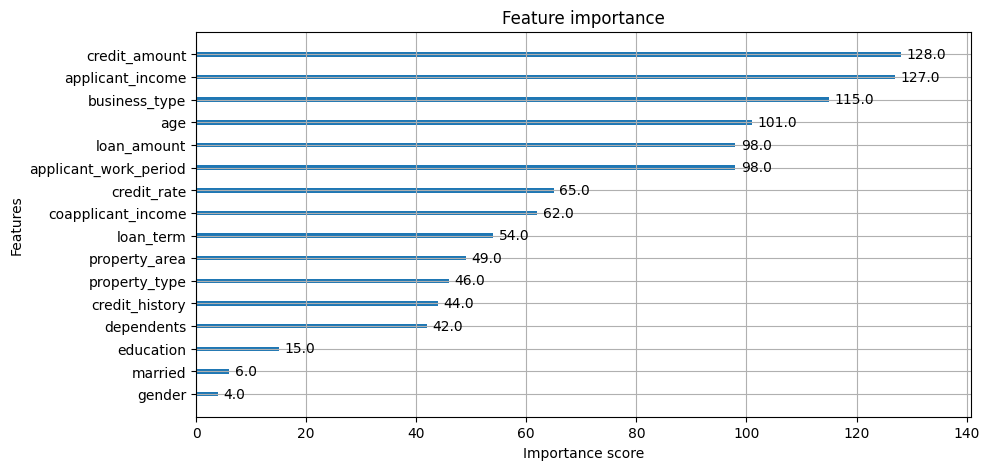

In [ ]:
import xgboost
from matplotlib.pylab import rcParams

rcParams['figure.figsize']=10,5
xgboost.plot_importance(model)

In [ ]:
import shap

idx=15

print(x_train.iloc[idx,:])

shap.initjs()

explainer=shap.TreeExplainer(model)
shap_values=explainer.shap_values(x_train)

shap.force_plot(explainer.expected_value,
                shap_values[idx,:],
                x_train.iloc[idx,:])

gender                      1.0
age                        60.0
married                     1.0
dependents                  1.0
education                   1.0
self_employed               0.0
business_type              14.0
applicant_income         6400.0
applicant_work_period      38.0
coapplicant_income       7250.0
credit_history              0.0
credit_amount               0.0
property_area               1.0
property_type               3.0
credit_rate                 7.0
loan_amount              3240.0
loan_term                  28.0
Name: 181, dtype: float64


In [ ]:
shap.initjs()

shap.force_plot(explainer.expected_value,shap_values,x_train)

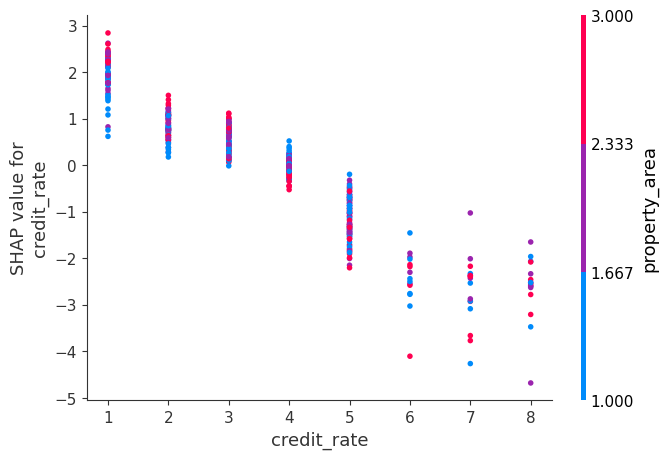

In [ ]:
shap.dependence_plot("credit_rate",shap_values,x_train)

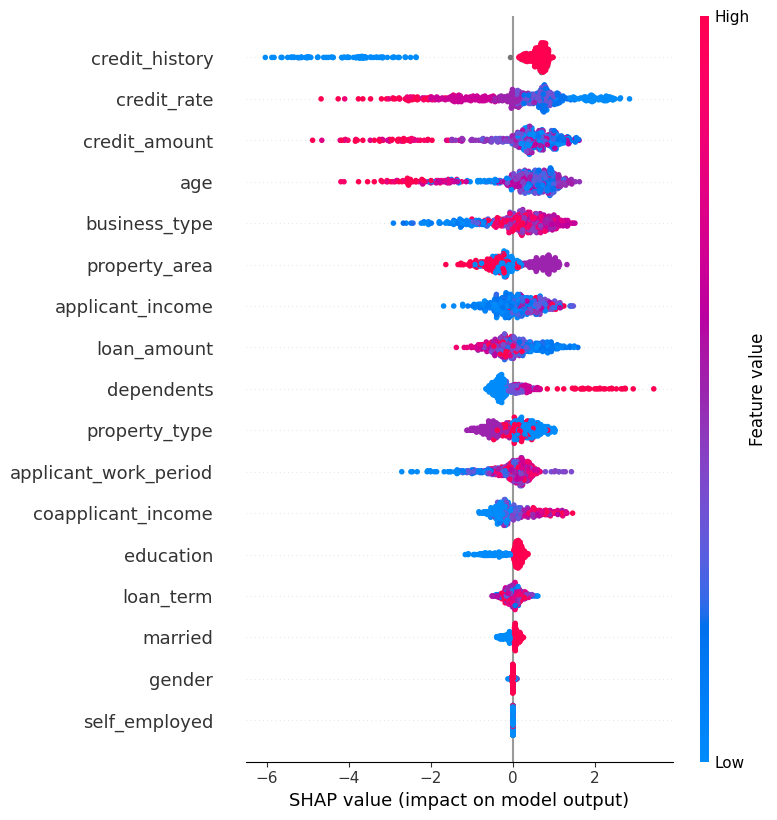

In [ ]:
shap.summary_plot(shap_values,x_train)

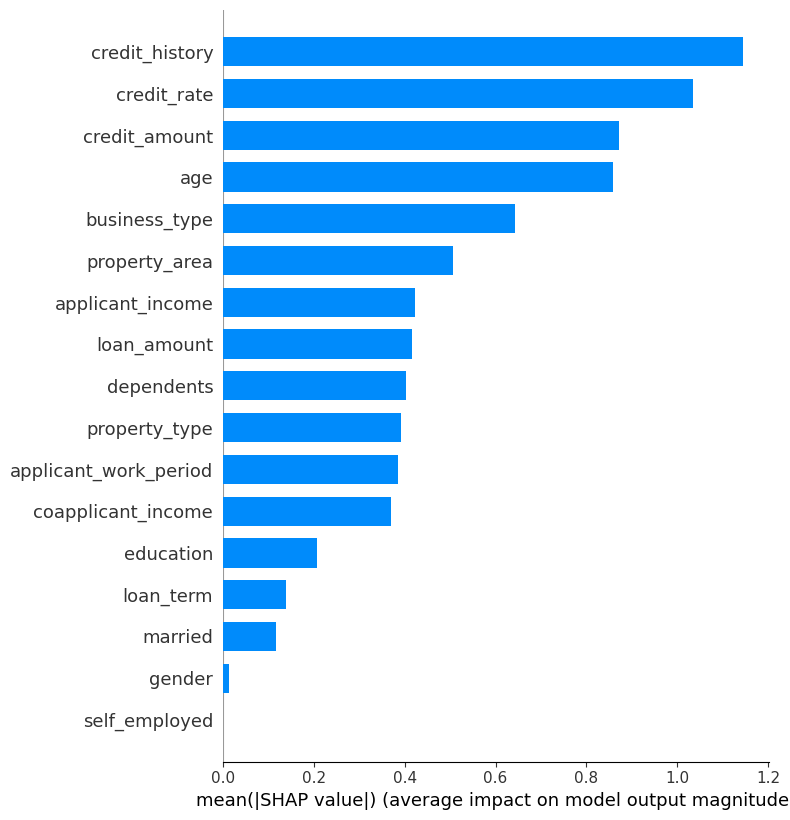

In [ ]:
shap.summary_plot(shap_values,x_train,plot_type="bar")

In [ ]:
loan_data=loan_data.drop(columns='education')

X=loan_data.loc[:,'gender':'loan_term']
y=loan_data.loc[:,'loan_status']

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)

model=XGBClassifier(
    booster='gbtree',
    objective='binary:logistic',
    learning_rate=0.02,
    n_estimators=300,
    reg_alpha=0.7,
    reg_lambda=0.5,
    max_depth=4,
)

model.fit(x_train,y_train)
calculate_accuracy(model,x_test,y_test)

Accuracy:85.37%


0.8536585365853658